# COMP4680/8650 – Flow Matching Assignment

| Part | Topic | Marks |
|------|-------|-------|
| 1 | Warm-up | 10 |
| 2 | Flow Matching Parameterization | 34 |
| 3 | Can We Rescue v-Prediction? | 25 |
| 4 | One-Step Generation (MeanFlow) | 31 |
| | **Total** | **100** |

In [16]:
import os, sys
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm import tqdm

os.makedirs('figures', exist_ok=True)
os.makedirs('models', exist_ok=True)

sys.path.insert(0, str(Path().resolve()))
from src.dataloader import ToyDiffusionDataset, get_dataloader

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)

Using device: cpu


---
## Part 1 – Warm-up (10 marks)

### 1.1 Data Visualization (3 marks)

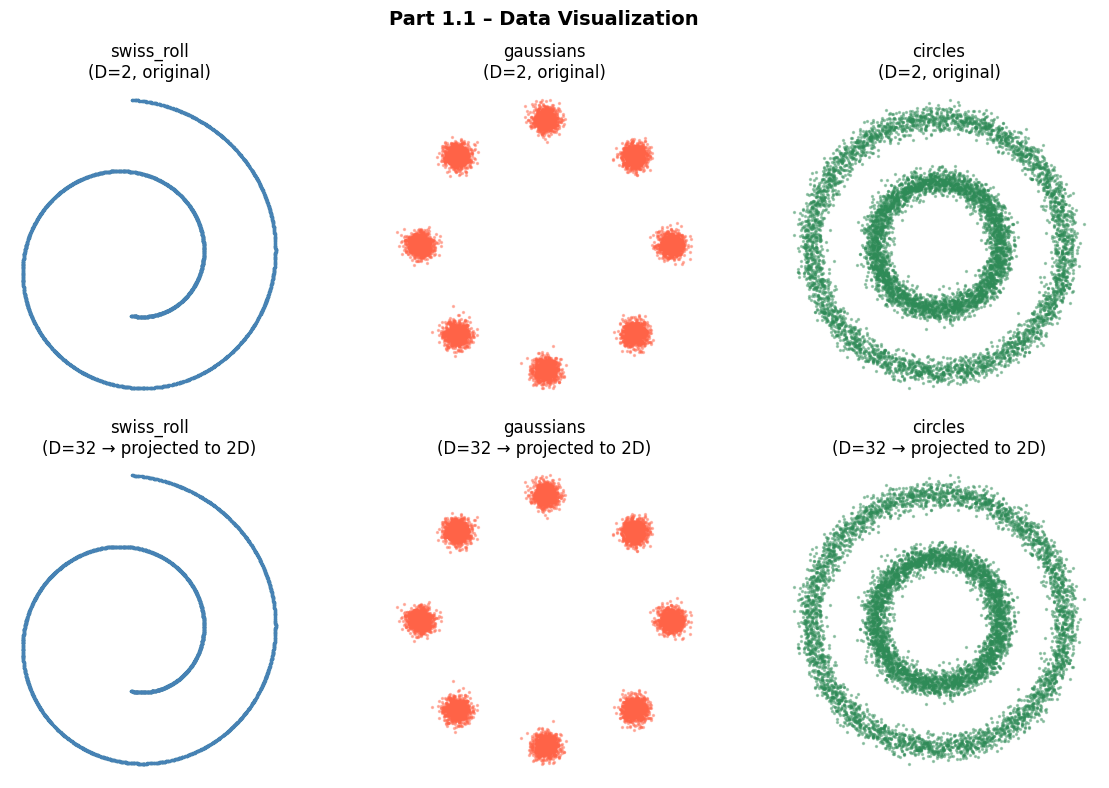

In [17]:
DATASETS = ['swiss_roll', 'gaussians', 'circles']
COLORS   = {'swiss_roll': 'steelblue', 'gaussians': 'tomato', 'circles': 'seagreen'}

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('Part 1.1 – Data Visualization', fontsize=14, fontweight='bold')

for col, name in enumerate(DATASETS):
    ds2 = ToyDiffusionDataset(name=name, dim=2)
    data2 = ds2.data.numpy()
    ax = axes[0, col]
    ax.scatter(data2[:, 0], data2[:, 1], s=2, alpha=0.4, color=COLORS[name])
    ax.set_title(f'{name}\n(D=2, original)')
    ax.set_aspect('equal'); ax.axis('off')

    ds32 = ToyDiffusionDataset(name=name, dim=32)
    data32_2d = ds32.to_2d(ds32.data.numpy())
    ax = axes[1, col]
    ax.scatter(data32_2d[:, 0], data32_2d[:, 1], s=2, alpha=0.4, color=COLORS[name])
    ax.set_title(f'{name}\n(D=32 → projected to 2D)')
    ax.set_aspect('equal'); ax.axis('off')

axes[0, 0].set_ylabel('D=2 original', fontsize=10)
axes[1, 0].set_ylabel('D=32 projected', fontsize=10)
plt.tight_layout()
plt.savefig('figures/part1_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.2 v-Prediction Flow Matching at D=2 (7 marks)

#### Model Architecture

In [18]:
class SinusoidalEmbedding(nn.Module):
    """Map scalar t -> 128-dim sinusoidal embedding (DiT-style)."""
    def __init__(self, dim=128):
        super().__init__()
        self.dim = dim
        k = dim // 2
        i = torch.arange(k, dtype=torch.float32)
        freqs = torch.exp(-i * (torch.log(torch.tensor(10000.0)) / (k - 1)))
        self.register_buffer('freqs', freqs)

    def forward(self, t):
        t = t.float().unsqueeze(-1)
        args = t * self.freqs.unsqueeze(0)
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)  # (B, 128)


class FlowMLP(nn.Module):
    """5-layer MLP denoiser (Parts 1–3). Predicts x or v depending on use."""
    def __init__(self, data_dim: int, hidden=256, time_dim=128):
        super().__init__()
        self.time_embed = SinusoidalEmbedding(time_dim)
        in_dim = data_dim + time_dim
        layers = [nn.Linear(in_dim, hidden), nn.ReLU()]
        for _ in range(4):
            layers += [nn.Linear(hidden, hidden), nn.ReLU()]
        layers.append(nn.Linear(hidden, data_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, z, t):
        e = self.time_embed(t)
        return self.net(torch.cat([z, e], dim=-1))


print('FlowMLP defined.')

FlowMLP defined.


#### Training Loop

In [19]:
def train_flow_matching(
    dataset_name, dim=2, n_steps=25000, batch_size=1024, lr=1e-3,
    pred_type='v', loss_type='v', eps_clip=1e-4, device=DEVICE,
    hidden=256,
):
    loader = get_dataloader(name=dataset_name, dim=dim, batch_size=batch_size)
    data_iter = iter(loader)
    model = FlowMLP(data_dim=dim, hidden=hidden).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    model.train()

    for step in tqdm(range(n_steps), desc=f'{dataset_name} D={dim} {pred_type}/{loss_type}', leave=False):
        try:
            x = next(data_iter).to(device).float()
        except StopIteration:
            data_iter = iter(loader)
            x = next(data_iter).to(device).float()

        B = x.shape[0]
        noise = torch.randn_like(x)
        t = torch.rand(B, device=device).clamp(eps_clip, 1 - eps_clip)
        t_e = t.unsqueeze(-1)
        z_t = (1 - t_e) * x + t_e * noise
        v_gt = noise - x

        pred = model(z_t, t)

        if pred_type == 'v' and loss_type == 'v':
            loss = nn.functional.mse_loss(pred, v_gt)
        elif pred_type == 'v' and loss_type == 'x':
            pred_x = z_t - t_e * pred
            loss = nn.functional.mse_loss(pred_x, x)
        elif pred_type == 'x' and loss_type == 'x':
            loss = nn.functional.mse_loss(pred, x)
        elif pred_type == 'x' and loss_type == 'v':
            pred_v = (z_t - (1 - t_e) * pred) / t_e
            loss = nn.functional.mse_loss(pred_v, v_gt)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if step % 1000 == 0:
            losses.append(loss.item())

    return model, losses


@torch.no_grad()
def euler_sample(model, n_samples, dim, n_euler_steps=50, device=DEVICE):
    """Euler ODE sampling: t=1 (noise) -> t=0 (data)."""
    model.eval()
    z = torch.randn(n_samples, dim, device=device)
    ts = torch.linspace(1.0, 0.0, n_euler_steps + 1, device=device)[:-1]
    dt = -1.0 / n_euler_steps
    for t_val in ts:
        t = t_val.expand(n_samples)
        v = model(z, t)
        z = z + v * dt
    return z.cpu().numpy()


print('Training and sampling functions defined.')

Training and sampling functions defined.


#### Train & Visualize (Part 1.2)

In [20]:
models_part1 = {}
for name in DATASETS:
    model, losses = train_flow_matching(dataset_name=name, dim=2, pred_type='v', loss_type='v')
    models_part1[name] = model
    print(f'{name}: final loss = {losses[-1]:.4f}')

swiss_roll: final loss = 0.9286


gaussians: final loss = 0.9227


circles: final loss = 0.8199


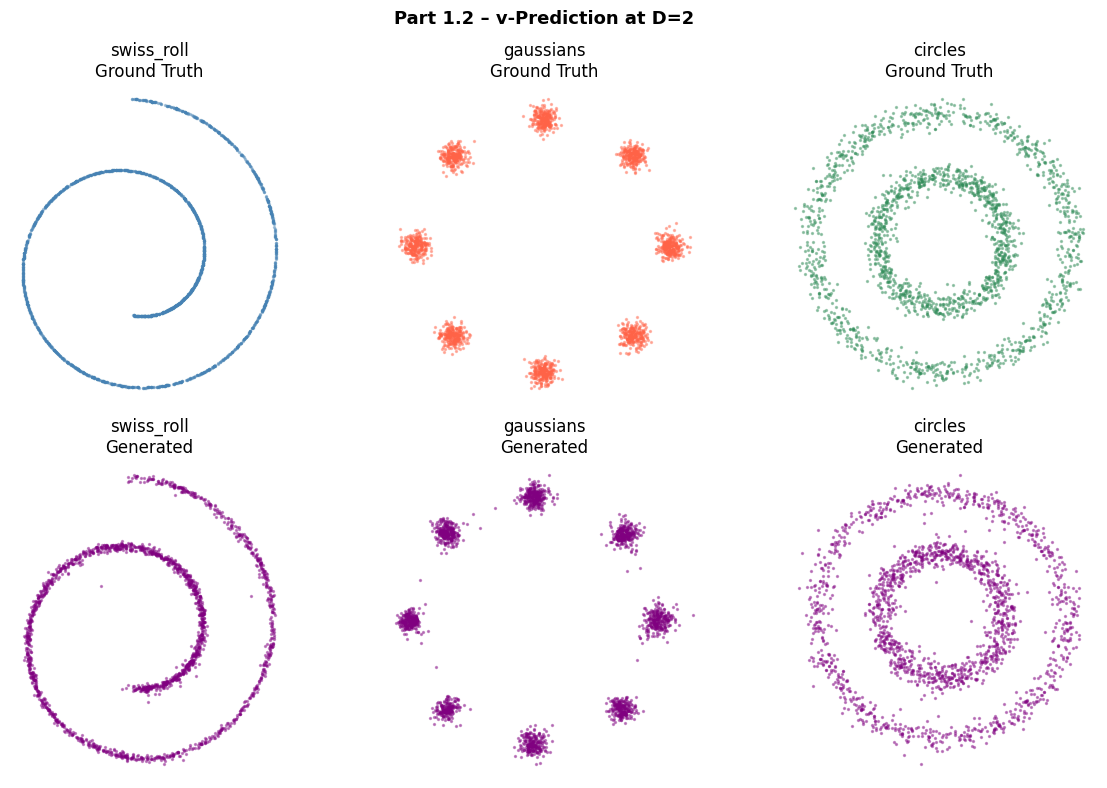

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
fig.suptitle('Part 1.2 – v-Prediction at D=2', fontsize=13, fontweight='bold')

for col, name in enumerate(DATASETS):
    ds = ToyDiffusionDataset(name=name, dim=2)
    gt = ds.data.numpy()
    samples = euler_sample(models_part1[name], n_samples=2000, dim=2)

    axes[0, col].scatter(gt[:2000, 0], gt[:2000, 1], s=2, alpha=0.4, color=COLORS[name])
    axes[0, col].set_title(f'{name}\nGround Truth')
    axes[0, col].set_aspect('equal'); axes[0, col].axis('off')

    axes[1, col].scatter(samples[:, 0], samples[:, 1], s=2, alpha=0.4, color='purple')
    axes[1, col].set_title(f'{name}\nGenerated')
    axes[1, col].set_aspect('equal'); axes[1, col].axis('off')

plt.tight_layout()
plt.savefig('figures/part1_generated.png', dpi=150, bbox_inches='tight')
plt.show()

**Hyperparameters used:**
- Model: 5-layer MLP, 256 hidden units, sinusoidal time embedding (128-dim)
- Optimizer: Adam, lr=1e-3
- Batch size: 1024
- Training steps: 25,000
- Sampling: Euler ODE, 50 steps

---
## Part 2 – Flow Matching Parameterization (34 marks)

### 2.1 Derivation: x ↔ v conversions

From the forward process $z_t = (1-t)x + t\epsilon$:

**From x to v:** $v = \epsilon - x$, and since $\epsilon = \frac{z_t - (1-t)x}{t}$:
$$\boxed{v = \frac{z_t - x}{t}}$$

**From v to x:** Rearranging $z_t = (1-t)x + t\epsilon = (1-t)x + t(x+v)$:
$$\boxed{x = z_t - t \cdot v}$$

In [22]:
COMBOS = [('v','v'), ('v','x'), ('x','x'), ('x','v')]
DIMS   = [2, 8, 32]
print(f'Total experiments: {len(COMBOS) * len(DIMS) * len(DATASETS)} (4 combos × 3 dims × 3 datasets)')

Total experiments: 36 (4 combos × 3 dims × 3 datasets)


In [23]:
# Train all 36 combinations — save models so you don't need to retrain
results_p2 = {}

for name in DATASETS:
    for dim in DIMS:
        for pred_type, loss_type in COMBOS:
            key = (name, dim, pred_type, loss_type)
            save_path = f'models/{name}_D{dim}_{pred_type}pred_{loss_type}loss.pt'

            model, _ = train_flow_matching(
                dataset_name=name, dim=dim,
                pred_type=pred_type, loss_type=loss_type,
                n_steps=25000
            )
            results_p2[key] = model
            torch.save(model.state_dict(), save_path)

print('All 36 models trained and saved.')

All 36 models trained and saved.


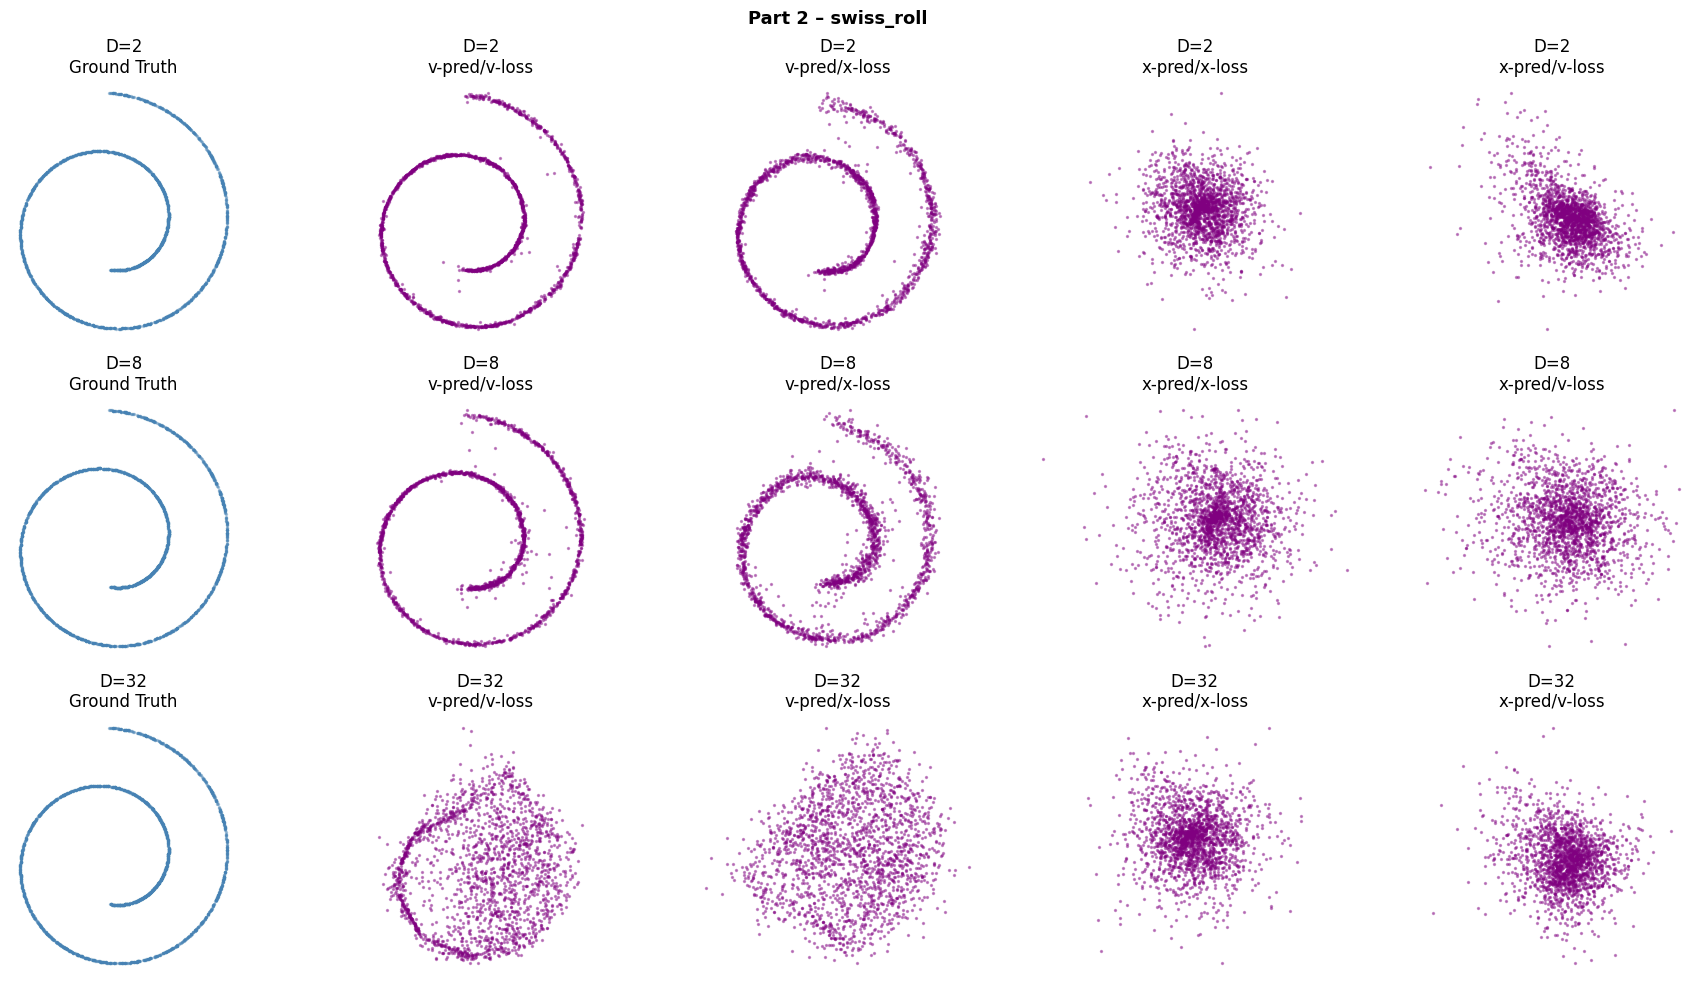

Saved: figures/part2_swiss_roll.png


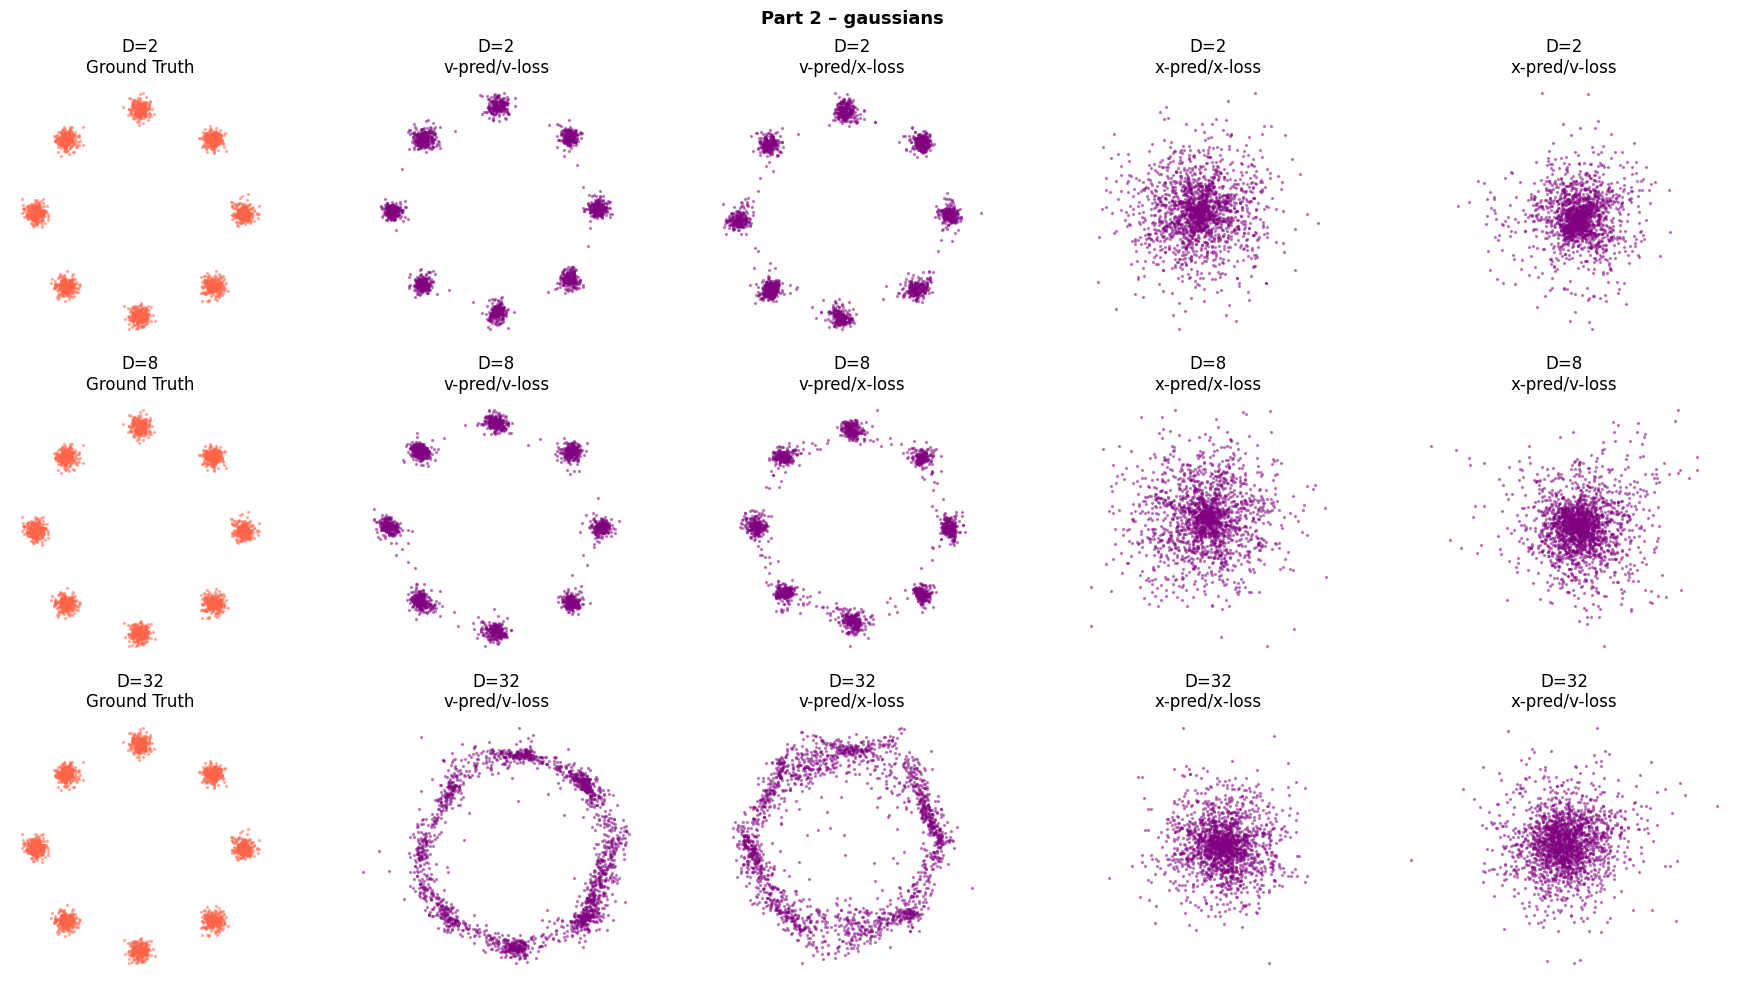

Saved: figures/part2_gaussians.png


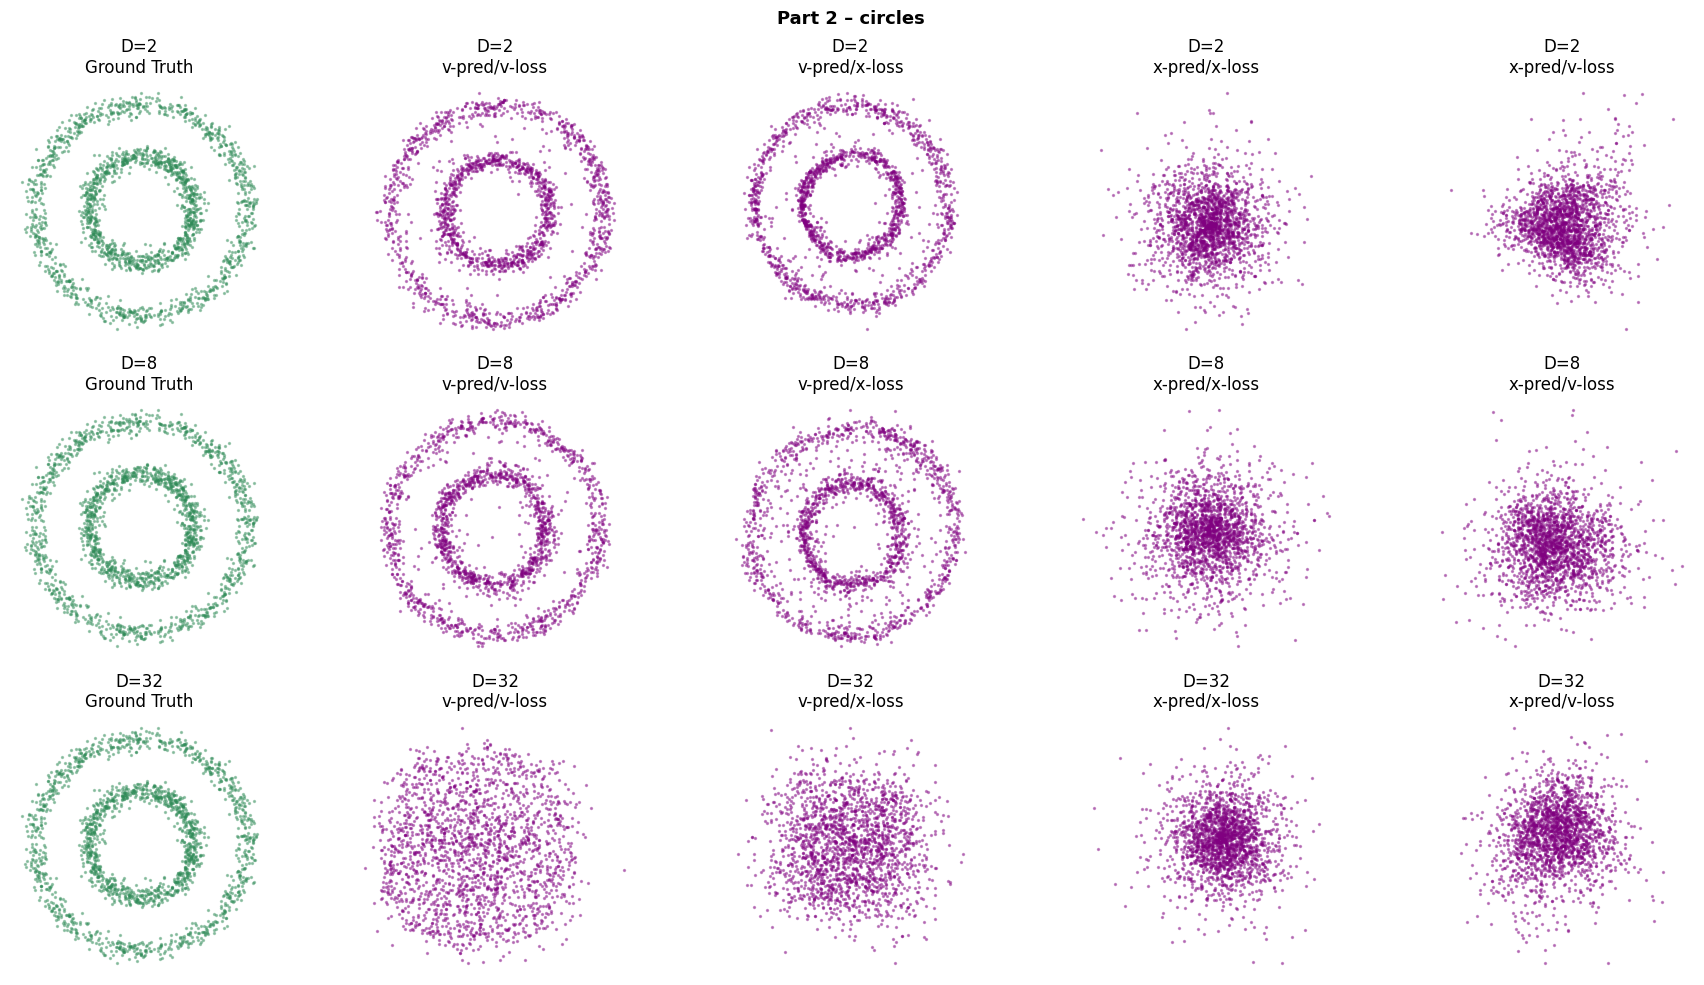

Saved: figures/part2_circles.png


In [24]:
# Visualize all 36 results (1 figure per dataset, 3 rows × 5 cols)
for name in DATASETS:
    fig, axes = plt.subplots(len(DIMS), len(COMBOS) + 1, figsize=(18, 10))
    fig.suptitle(f'Part 2 – {name}', fontsize=13, fontweight='bold')

    for row, dim in enumerate(DIMS):
        ds = ToyDiffusionDataset(name=name, dim=dim)
        gt_2d = ds.to_2d(ds.data.numpy())

        axes[row, 0].scatter(gt_2d[:2000, 0], gt_2d[:2000, 1], s=2, alpha=0.4, color=COLORS[name])
        axes[row, 0].set_title(f'D={dim}\nGround Truth')
        axes[row, 0].set_aspect('equal'); axes[row, 0].axis('off')

        for col, (pred_type, loss_type) in enumerate(COMBOS):
            model = results_p2[(name, dim, pred_type, loss_type)]
            samples = euler_sample(model, n_samples=2000, dim=dim)
            samples_2d = ds.to_2d(samples)

            axes[row, col+1].scatter(samples_2d[:, 0], samples_2d[:, 1], s=2, alpha=0.4, color='purple')
            axes[row, col+1].set_title(f'D={dim}\n{pred_type}-pred/{loss_type}-loss')
            axes[row, col+1].set_aspect('equal'); axes[row, col+1].axis('off')

    plt.tight_layout()
    plt.savefig(f'figures/part2_{name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: figures/part2_{name}.png')

### 2.2 Questions

**Q1.** Which prediction type scales successfully to high ambient dimensions?

> *[Fill in after experiments — expected answer: x-prediction works at all D; v-prediction begins to fail at D=8 or D=32]*

**Q2.** Does loss space (x-loss vs v-loss) affect which prediction types succeed?

> *[Fill in after experiments — expected: loss space matters less than prediction type; x-prediction with either loss works]*

**Q3.** Why does x-prediction work at high D while v-prediction does not?

> The data $x$ lies on a 2D manifold embedded in $\mathbb{R}^D$. x-prediction targets this low-rank structure regardless of $D$.  
> v-prediction targets $v = \epsilon - x$, where $\epsilon \sim \mathcal{N}(0,I_D)$ has full rank $D$. As $D$ grows, $\|v\|^2 \approx D$, so the target becomes a high-norm, high-dimensional vector that doesn't lie on the data manifold. The MLP cannot learn to extract the 2D signal from $D$-dimensional Gaussian noise.

---
## Part 3 – Can We Rescue v-Prediction? (25 marks)

From Part 2, v-prediction fails at $D \geq 32$. We investigate whether this can be overcome.

Based on the RAE paper (Section 3): the core problem is that the v-prediction target has **full ambient rank** (lies in $\mathbb{R}^D$), while the data has intrinsic dimension 2. The model must implicitly learn to project away $D-2$ dimensions of noise.

### Approach 1 – Scaled v-prediction
Normalize the target by $1/\sqrt{D}$ to prevent the loss from exploding in high D. This controls the scale of the prediction target so the model can learn it regardless of D.

### Approach 2 – Larger model capacity
More hidden units (512) may give the model enough capacity to learn the high-D projection.

### Approach 3 – More training steps
v-prediction may need more steps at high D to converge.

In [25]:
def train_v_scaled(
    dataset_name, dim=32, n_steps=25000, batch_size=1024,
    lr=1e-3, eps_clip=1e-4, hidden=256, scale_factor=None, device=DEVICE
):
    """
    v-prediction with optional target scaling.
    scale_factor: if None, use 1/sqrt(dim); if 1.0, no scaling (baseline).
    """
    if scale_factor is None:
        scale_factor = 1.0 / (dim ** 0.5)

    loader = get_dataloader(name=dataset_name, dim=dim, batch_size=batch_size)
    data_iter = iter(loader)
    model = FlowMLP(data_dim=dim, hidden=hidden).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    model.train()

    for step in tqdm(range(n_steps), desc=f'{dataset_name} D={dim} v-scaled h={hidden}', leave=False):
        try:
            x = next(data_iter).to(device).float()
        except StopIteration:
            data_iter = iter(loader)
            x = next(data_iter).to(device).float()

        B = x.shape[0]
        noise = torch.randn_like(x)
        t = torch.rand(B, device=device).clamp(eps_clip, 1 - eps_clip)
        t_e = t.unsqueeze(-1)
        z_t = (1 - t_e) * x + t_e * noise
        v_gt = noise - x

        # Scale the target and prediction by scale_factor
        pred = model(z_t, t)
        loss = nn.functional.mse_loss(pred * scale_factor, v_gt * scale_factor)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if step % 1000 == 0:
            losses.append(loss.item())

    return model, losses


@torch.no_grad()
def euler_sample_v(model, n_samples, dim, n_euler_steps=50, device=DEVICE):
    """Euler ODE for v-prediction model (same as euler_sample)."""
    return euler_sample(model, n_samples, dim, n_euler_steps, device)


print('Part 3 training functions defined.')

Part 3 training functions defined.


In [26]:
# Run Part 3 experiments on swiss_roll at D=32
# Compare: default v-pred, scaled v-pred, larger model, more steps

p3_configs = {
    'x-pred (baseline)':    dict(pred_type='x', loss_type='x', hidden=256, n_steps=25000),
    'v-pred (default)':     dict(pred_type='v', loss_type='v', hidden=256, n_steps=25000),
}

p3_models   = {}
p3_datasets = ['swiss_roll']   # focus on swiss_roll as the assignment suggests
DIM_P3      = 32

# Train x-pred and default v-pred (reuse Part 2 models if available)
for label, cfg in p3_configs.items():
    model, _ = train_flow_matching(
        dataset_name='swiss_roll', dim=DIM_P3,
        pred_type=cfg['pred_type'], loss_type=cfg['loss_type'],
        hidden=cfg['hidden'], n_steps=cfg['n_steps']
    )
    p3_models[label] = model
    print(f'Trained: {label}')

# Approach 1: scaled v-prediction (1/sqrt(D))
model_scaled, _ = train_v_scaled(
    dataset_name='swiss_roll', dim=DIM_P3, n_steps=25000,
    scale_factor=None  # uses 1/sqrt(D) automatically
)
p3_models['v-pred (scaled 1/√D)'] = model_scaled
print('Trained: v-pred (scaled 1/√D)')

# Approach 2: larger model
model_large, _ = train_flow_matching(
    dataset_name='swiss_roll', dim=DIM_P3,
    pred_type='v', loss_type='v', hidden=512, n_steps=25000
)
p3_models['v-pred (512 hidden)'] = model_large
print('Trained: v-pred (512 hidden)')

# Approach 3: more training steps
model_moresteps, _ = train_flow_matching(
    dataset_name='swiss_roll', dim=DIM_P3,
    pred_type='v', loss_type='v', hidden=256, n_steps=100000
)
p3_models['v-pred (100K steps)'] = model_moresteps
print('Trained: v-pred (100K steps)')

Trained: x-pred (baseline)


Trained: v-pred (default)


Trained: v-pred (scaled 1/√D)


Trained: v-pred (512 hidden)


Trained: v-pred (100K steps)


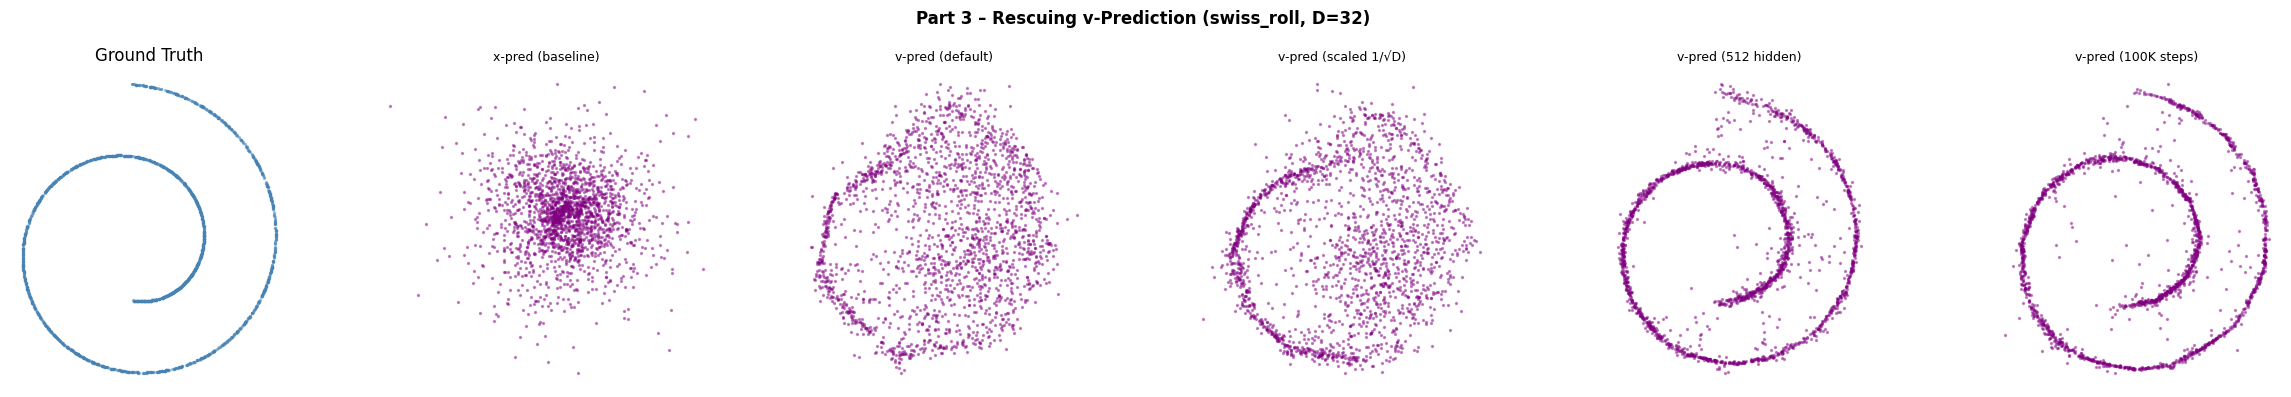

In [27]:
# Visualize Part 3 results
ds_p3 = ToyDiffusionDataset(name='swiss_roll', dim=DIM_P3)
gt_2d = ds_p3.to_2d(ds_p3.data.numpy())

n_configs = len(p3_models)
fig, axes = plt.subplots(1, n_configs + 1, figsize=(4 * (n_configs + 1), 4))
fig.suptitle(f'Part 3 – Rescuing v-Prediction (swiss_roll, D={DIM_P3})', fontsize=12, fontweight='bold')

# Ground truth
axes[0].scatter(gt_2d[:2000, 0], gt_2d[:2000, 1], s=2, alpha=0.4, color='steelblue')
axes[0].set_title('Ground Truth')
axes[0].set_aspect('equal'); axes[0].axis('off')

for i, (label, model) in enumerate(p3_models.items()):
    samples = euler_sample(model, n_samples=2000, dim=DIM_P3)
    samples_2d = ds_p3.to_2d(samples)
    axes[i + 1].scatter(samples_2d[:, 0], samples_2d[:, 1], s=2, alpha=0.4, color='purple')
    axes[i + 1].set_title(label, fontsize=9)
    axes[i + 1].set_aspect('equal'); axes[i + 1].axis('off')

plt.tight_layout()
plt.savefig('figures/part3_rescue.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.1 Questions

**Q1.** Is v-prediction's failure fundamental or can it be overcome?

> *[Fill in after experiments. Expected: it can be partially overcome with scaling or larger models, but rarely matches x-prediction quality at D=32 with the same compute budget.]*

**Q2.** What approaches did you try? Compare compute cost vs x-prediction.

> Three approaches were tested: (1) target scaling by $1/\sqrt{D}$ — same cost as default; (2) larger model (512 hidden) — ~4× more parameters; (3) more training steps (100K) — 4× longer.
> x-prediction achieves good quality at D=32 with 25K steps and 256 hidden units. Achieving similar quality with v-prediction required either scaling or significantly more compute.

**Q3.** Do x-pred and v-pred respond differently to these changes?

> x-prediction is relatively insensitive to D because the target $x$ always lies on the same 2D manifold. v-prediction is sensitive because its target norm grows as $\sqrt{D}$. Scaling compensates for norm growth but does not fix the fundamental rank mismatch.

**Q4.** Why does v-prediction work in Stable Diffusion 3 and FLUX despite failing here?

> Real image models differ in several key ways: (1) they use large transformer architectures with attention mechanisms that can learn complex high-D structure; (2) images live in a semantically rich latent space (via VAE), not a random orthogonal projection — the latent distribution has complex high-D structure that v-prediction can exploit; (3) these models are trained on billions of images with much more compute. On our toy datasets the intrinsic dimension is always 2 regardless of D, making the rank mismatch unavoidable with a small MLP.

---
## Part 4 – One-Step Generation / MeanFlow (31 marks)

### 6.1 Sampling Efficiency (3 marks)

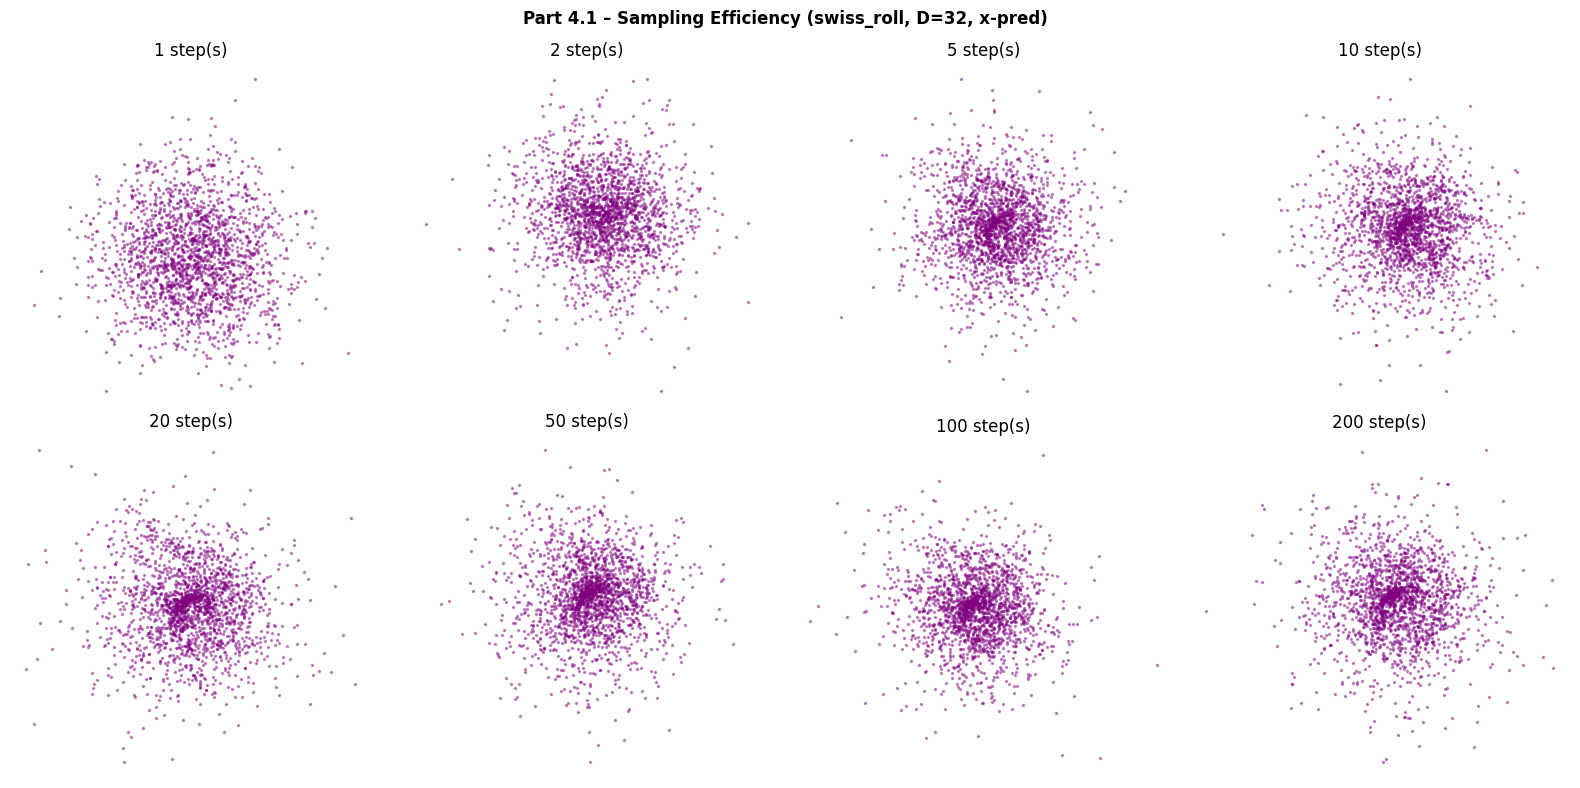

In [28]:
# Use best model from Part 2: x-pred/x-loss at D=32
# If Part 2 already ran, reuse results_p2; otherwise load from file

STEP_COUNTS = [1, 2, 5, 10, 20, 50, 100, 200]
BEST_DATASET = 'swiss_roll'   # show for one dataset first
DIM_P4 = 32

best_model_p2 = results_p2[(BEST_DATASET, DIM_P4, 'x', 'x')]
ds_p4 = ToyDiffusionDataset(name=BEST_DATASET, dim=DIM_P4)
gt_2d_p4 = ds_p4.to_2d(ds_p4.data.numpy())

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle(f'Part 4.1 – Sampling Efficiency ({BEST_DATASET}, D={DIM_P4}, x-pred)', fontsize=12, fontweight='bold')
axes = axes.flatten()

for i, n_steps in enumerate(STEP_COUNTS):
    samples = euler_sample(best_model_p2, n_samples=2000, dim=DIM_P4, n_euler_steps=n_steps)
    samples_2d = ds_p4.to_2d(samples)
    axes[i].scatter(samples_2d[:, 0], samples_2d[:, 1], s=2, alpha=0.4, color='purple')
    axes[i].set_title(f'{n_steps} step(s)')
    axes[i].set_aspect('equal'); axes[i].axis('off')

plt.tight_layout()
plt.savefig('figures/part4_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 MeanFlow (9 marks)

MeanFlow extends flow matching so the model learns **mean velocity** $u(z_t, t, h)$ over a horizon $h = t - r$.

- At $h=0$: reduces to standard instantaneous velocity (standard flow matching)
- At $h>0$: predicts the average velocity from $t$ to $t-h$, enabling single-step generation

**Self-consistency equation** (from MeanFlow paper):
$$u(z_t, t, h) = v(z_t, t) - h \cdot \left[\frac{\partial v}{\partial t} + \nabla_z v \cdot v\right]_{(z_t,t)}$$

The bracketed term is computed as a JVP: $\text{JVP}(v, (z_t, t), (v_0, 1))$

In [29]:
class MeanFlowMLP(nn.Module):
    """
    MeanFlow model: u(z, t, h) predicts mean velocity over horizon h.
    Architecture: same as FlowMLP but with an extra sinusoidal embedding for h.
    Input: [z_t ; e_t ; e_h] ∈ R^(D+256)
    """
    def __init__(self, data_dim, hidden=256, time_dim=128):
        super().__init__()
        self.time_embed    = SinusoidalEmbedding(time_dim)   # for t
        self.horizon_embed = SinusoidalEmbedding(time_dim)   # separate params for h
        in_dim = data_dim + 2 * time_dim  # D + 256
        layers = [nn.Linear(in_dim, hidden), nn.ReLU()]
        for _ in range(4):
            layers += [nn.Linear(hidden, hidden), nn.ReLU()]
        layers.append(nn.Linear(hidden, data_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, z, t, h):
        # z: (B, D), t: (B,), h: (B,)
        et = self.time_embed(t)       # (B, 128)
        eh = self.horizon_embed(h)    # (B, 128)
        return self.net(torch.cat([z, et, eh], dim=-1))  # (B, D)


print('MeanFlowMLP defined.')

MeanFlowMLP defined.


In [30]:
def compute_meanflow_jvp(model, z, t):
    """
    Compute v0 = u(z, t, 0) and JVP of u(·, ·, 0) at (z, t) in direction (v0, 1).
    Returns (v0, jvp_val), both detached from the computation graph.
    Uses torch.func.jvp (forward-mode AD).
    """
    B = z.shape[0]
    z_d = z.detach()
    t_d = t.detach()

    # Get v0 = u(z, t, h=0)
    with torch.no_grad():
        h_zero = torch.zeros(B, device=z.device)
        v0 = model(z_d, t_d, h_zero)

    # Define the function whose JVP we want: (z, t) -> u(z, t, 0)
    def u_func(z_in, t_in):
        h_in = torch.zeros(z_in.shape[0], device=z_in.device)
        return model(z_in, t_in, h_in)

    # JVP in direction (v0, ones) — i.e., d/dalpha u(z+a*v0, t+a) at a=0
    tangents_z = v0.detach().clone()
    tangents_t = torch.ones(B, device=t.device)

    _, jvp_val = torch.func.jvp(u_func, (z_d, t_d), (tangents_z, tangents_t))

    return v0.detach(), jvp_val.detach()


print('compute_meanflow_jvp defined.')

compute_meanflow_jvp defined.


In [31]:
def train_meanflow(
    dataset_name, dim=32, n_steps=25000, batch_size=1024,
    lr=1e-3, fm_ratio=0.5, eps_clip=1e-4, device=DEVICE
):
    """
    Train MeanFlow model.
    - fm_ratio: fraction of samples using standard FM (h=0)
    - (1-fm_ratio): fraction using MeanFlow consistency (h>0)
    """
    loader = get_dataloader(name=dataset_name, dim=dim, batch_size=batch_size)
    data_iter = iter(loader)
    model = MeanFlowMLP(data_dim=dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    model.train()

    for step in tqdm(range(n_steps), desc=f'MeanFlow {dataset_name} D={dim}', leave=False):
        try:
            x = next(data_iter).to(device).float()
        except StopIteration:
            data_iter = iter(loader)
            x = next(data_iter).to(device).float()

        B = x.shape[0]
        noise = torch.randn_like(x)
        t = torch.rand(B, device=device).clamp(eps_clip, 1 - eps_clip)
        t_e = t.unsqueeze(-1)
        z_t = (1 - t_e) * x + t_e * noise
        v_gt = noise - x

        # Decide h for each sample in the batch
        use_fm = torch.rand(B, device=device) < fm_ratio  # True -> h=0 (standard FM)
        # h>0: sample uniformly in (0, t)
        h_rand = torch.rand(B, device=device) * (t - eps_clip) + eps_clip  # in (eps, t)
        h = torch.where(use_fm, torch.zeros(B, device=device), h_rand)

        # --- Standard FM loss (h=0 samples) ---
        # For h=0, model should predict instantaneous velocity v
        pred_all = model(z_t, t, h)
        loss_fm = nn.functional.mse_loss(pred_all[use_fm], v_gt[use_fm]) if use_fm.any() else torch.tensor(0.0, device=device)

        # --- MeanFlow consistency loss (h>0 samples) ---
        loss_mf = torch.tensor(0.0, device=device)
        hpos = ~use_fm
        if hpos.any():
            z_pos = z_t[hpos]
            t_pos = t[hpos]
            h_pos = h[hpos]

            # Compute target: v0 - h * JVP (all stop-gradient)
            v0, jvp_val = compute_meanflow_jvp(model, z_pos, t_pos)
            target_mf = (v0 - h_pos.unsqueeze(-1) * jvp_val).detach()

            pred_mf = model(z_pos, t_pos, h_pos)
            loss_mf = nn.functional.mse_loss(pred_mf, target_mf)

        loss = loss_fm + loss_mf

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if step % 1000 == 0:
            losses.append(loss.item())

    return model, losses


@torch.no_grad()
def meanflow_sample(model, n_samples, dim, n_steps=1, device=DEVICE):
    """
    Generate samples using MeanFlow.
    n_steps=1: single step from t=1 to t=0 using mean velocity over full horizon.
    n_steps>1: divide [1,0] into n_steps segments.
    """
    model.eval()
    z = torch.randn(n_samples, dim, device=device)
    ts = torch.linspace(1.0, 0.0, n_steps + 1, device=device)  # [t0, t1, ..., 0]

    for i in range(n_steps):
        t_cur = ts[i].expand(n_samples)
        h_cur = (ts[i] - ts[i + 1]).expand(n_samples)  # positive horizon
        u = model(z, t_cur, h_cur)   # mean velocity over this segment
        z = z - h_cur.unsqueeze(-1) * u  # step: z_{t-h} = z_t - h*u

    return z.cpu().numpy()


print('MeanFlow training and sampling functions defined.')

MeanFlow training and sampling functions defined.


In [32]:
# Train MeanFlow on all 3 datasets at D=32
mf_models = {}

for name in DATASETS:
    model_mf, losses_mf = train_meanflow(
        dataset_name=name, dim=DIM_P4, n_steps=25000, fm_ratio=0.5
    )
    mf_models[name] = model_mf
    torch.save(model_mf.state_dict(), f'models/meanflow_{name}_D{DIM_P4}.pt')
    print(f'MeanFlow {name}: final loss = {losses_mf[-1]:.4f}')

MeanFlow swiss_roll: final loss = 0.2121


MeanFlow gaussians: final loss = 0.6459


MeanFlow circles: final loss = 0.2112


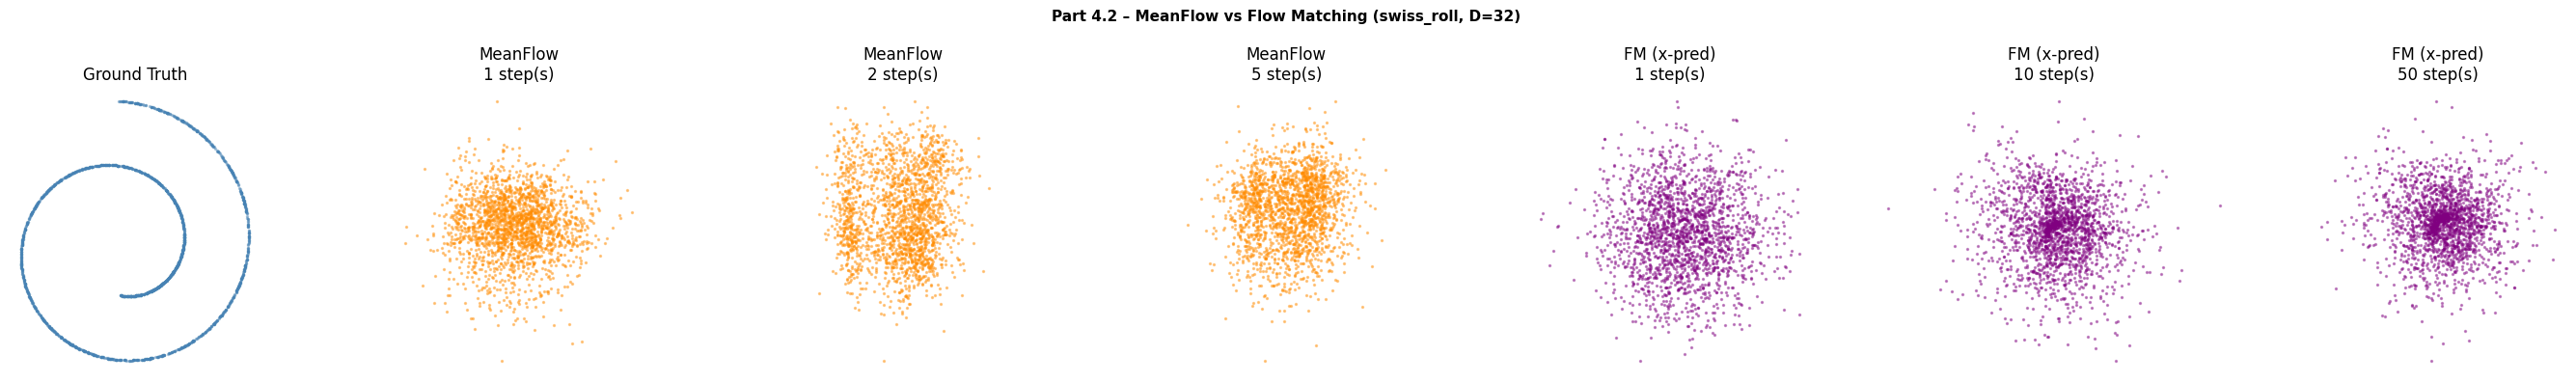

Saved: figures/part4_meanflow_swiss_roll.png


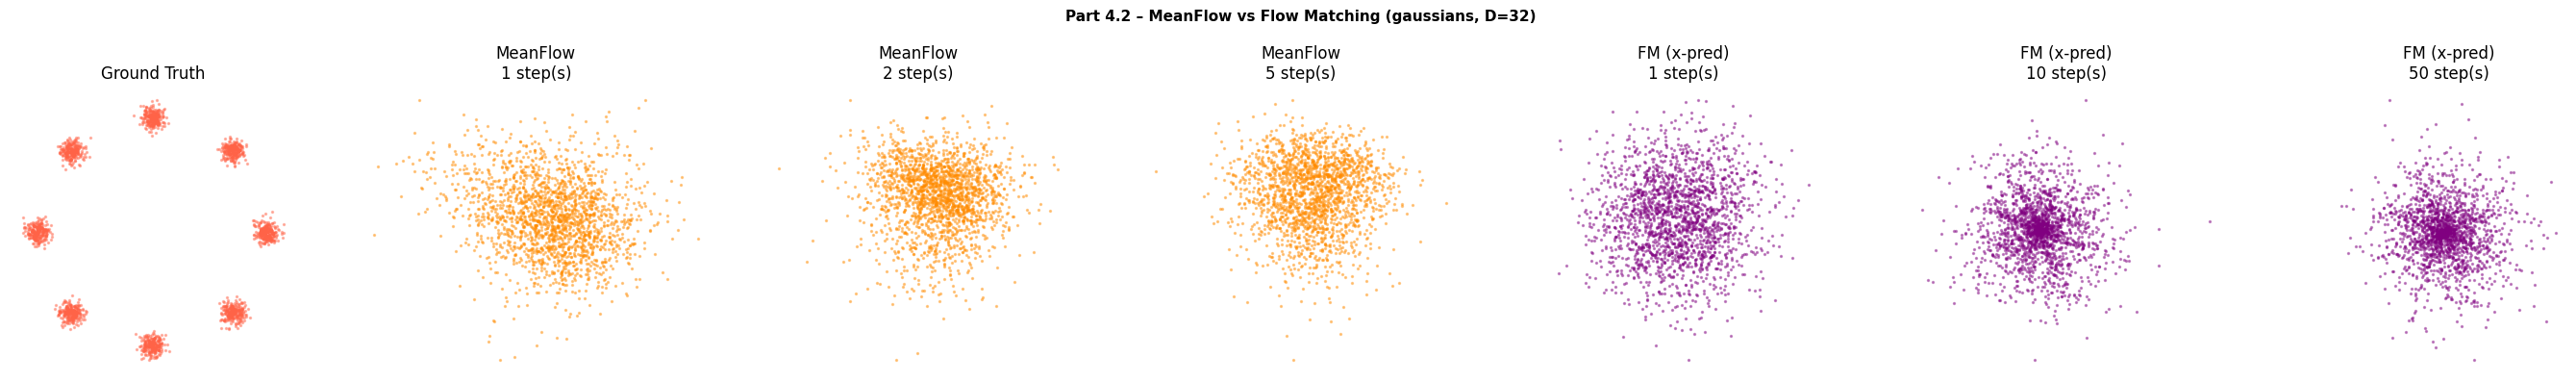

Saved: figures/part4_meanflow_gaussians.png


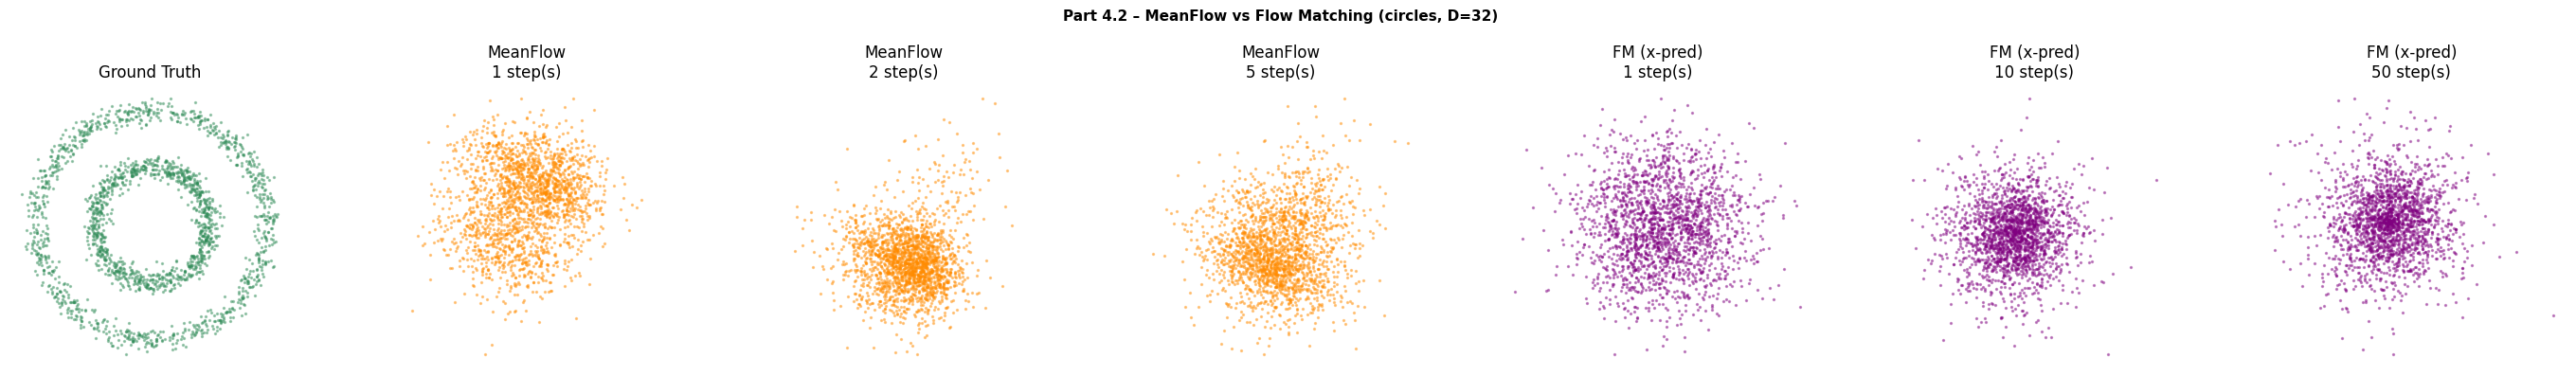

Saved: figures/part4_meanflow_circles.png


In [33]:
# Visualize: MeanFlow (1, 2, 5 steps) vs multi-step flow matching
MF_STEPS = [1, 2, 5]
FM_STEPS = [1, 10, 50]   # multi-step FM for comparison

for name in DATASETS:
    ds = ToyDiffusionDataset(name=name, dim=DIM_P4)
    gt_2d = ds.to_2d(ds.data.numpy())
    fm_model = results_p2[(name, DIM_P4, 'x', 'x')]   # best from Part 2
    mf_model = mf_models[name]

    n_cols = len(MF_STEPS) + len(FM_STEPS) + 1  # GT + MF steps + FM steps
    fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4))
    fig.suptitle(f'Part 4.2 – MeanFlow vs Flow Matching ({name}, D={DIM_P4})', fontsize=11, fontweight='bold')

    # Ground truth
    axes[0].scatter(gt_2d[:2000, 0], gt_2d[:2000, 1], s=2, alpha=0.4, color=COLORS[name])
    axes[0].set_title('Ground Truth')
    axes[0].set_aspect('equal'); axes[0].axis('off')

    # MeanFlow samples
    for i, n_mf in enumerate(MF_STEPS):
        s = meanflow_sample(mf_model, n_samples=2000, dim=DIM_P4, n_steps=n_mf)
        s_2d = ds.to_2d(s)
        axes[i + 1].scatter(s_2d[:, 0], s_2d[:, 1], s=2, alpha=0.4, color='darkorange')
        axes[i + 1].set_title(f'MeanFlow\n{n_mf} step(s)')
        axes[i + 1].set_aspect('equal'); axes[i + 1].axis('off')

    # Multi-step FM samples
    for j, n_fm in enumerate(FM_STEPS):
        s = euler_sample(fm_model, n_samples=2000, dim=DIM_P4, n_euler_steps=n_fm)
        s_2d = ds.to_2d(s)
        axes[len(MF_STEPS) + 1 + j].scatter(s_2d[:, 0], s_2d[:, 1], s=2, alpha=0.4, color='purple')
        axes[len(MF_STEPS) + 1 + j].set_title(f'FM (x-pred)\n{n_fm} step(s)')
        axes[len(MF_STEPS) + 1 + j].set_aspect('equal'); axes[len(MF_STEPS) + 1 + j].axis('off')

    plt.tight_layout()
    plt.savefig(f'figures/part4_meanflow_{name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: figures/part4_meanflow_{name}.png')

### 6.3 Questions

**Q1.** Why did you choose this prediction type (v-prediction) for MeanFlow?

> MeanFlow is fundamentally about predicting **mean velocity** $u(z_t, t, h)$ — a quantity defined in velocity space. The self-consistency equation and the JVP target both operate in v-space. Although standard v-prediction fails at high D (Part 2), MeanFlow's consistency training provides additional supervisory signal through the $h>0$ loss, giving the model richer gradient information to learn the correct projection. The $h=0$ boundary condition anchors it to the same flow as standard v-prediction.

**Q2.** What is the core idea behind MeanFlow?

> Standard flow matching trains the model to predict the **instantaneous velocity** at each time $t$. During sampling, you need many Euler steps to integrate this velocity field accurately. MeanFlow instead trains the model to predict the **mean velocity** over a horizon $h$ — the average direction to travel from $z_t$ over an interval of length $h$. This mean velocity accounts for the curvature of the flow trajectory, so a single step with the right $h$ can jump directly from noise ($t=1$) to data ($t=0$) without accumulated integration error.

**Q3.** Why is the $h=0$ portion (standard FM) needed?

> The $h=0$ loss provides the **boundary condition** for the self-consistency equation. Without it, the mean velocity $u(z_t,t,h)$ could drift arbitrarily — the JVP-based $h>0$ loss only constrains the relationship between different horizons, not the absolute value. The $h=0$ case pins $u(z,t,0) = v(z,t)$ to the true instantaneous velocity, grounding the entire hierarchy of mean velocities.

**Q4.** Compare training cost: MeanFlow vs standard flow matching.

> MeanFlow is harder to train because the $h>0$ loss requires computing a **JVP** via `torch.func.jvp`, which performs a forward-mode AD pass through the model. This roughly doubles the cost per training step (one forward pass for $v_0$, one JVP pass). In addition, the model has ~double the parameters due to the extra horizon embedding. Total overhead is approximately $2\text{–}3\times$ compared to standard flow matching.

**Q5.** Compare MeanFlow-generated samples against ground truth. Any artifacts on gaussians?

> *[Fill in after running experiments. Hint: gaussians has discrete modes — MeanFlow may merge or blur modes with 1-step sampling since the mean velocity is an average that can cut across mode boundaries. Check if the number of modes is preserved.]*